# CUAD Contract Understanding Dataset (Exploratory Data Analysis)

### Dataset Overview
The Contract Understanding Atticus Dataset (CUAD) is a collection of commercial legal contracts annotated with clauses that a lawyer would want to review. The contracts were taken from public filings, and the annotations were added by legal experts across 41 clause categories.

This notebook uses the training split in SQuAD-style JSON format (`train_separate_questions.json`), which contains 408 contracts.

## Dataset Loading

The analysis uses the CUAD training split containing 408 contracts.

In [1]:
import json
import pandas as pd

# open the CUAD training file and parse it into a Python dictionary
with open("/content/train_separate_questions.json", "r") as f:
    data = json.load(f)

print("Loaded successfully!")
print("Number of contracts:", len(data["data"])) # one entry per contract

Loaded successfully!
Number of contracts: 408


## Dataset Structure

The CUAD data is stored in JSON format. Each contract contains paragraphs, and each paragraph contains question-answer annotations corresponding to the 41 CUAD categories.

In [2]:
print(data.keys())
print(data["data"][0].keys())

dict_keys(['version', 'data'])
dict_keys(['title', 'paragraphs'])


This is the standard SQuAD-style layout: the dataset holds contracts, contracts hold paragraphs, and paragraphs hold questions and answers.

In [3]:
print(data["data"][0]["title"]) # first contracts name
print(data["data"][0]["paragraphs"][0]["qas"][0]) # first question-answer (QA) entry

LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
{'answers': [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}], 'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name_0', 'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract', 'is_impossible': False}


The first entry shows the fields of a single annotation: `answers` (the highlighted text plus its character offset, `answer_start`), `id`, `question` (the templated "Highlight the parts... related to 'Document Name'..." prompt), and `is_impossible` (whether no answer exists). This is the structure that gets flattened into a table below.

In [4]:
rows = []

for contract in data["data"]: # loop over contracts
    contract_id = contract["title"]

    for paragraph in contract["paragraphs"]: # loop over paragraphs in the contract
        for qa in paragraph["qas"]: # loop over questions (categories) in the paragraph
            rows.append({
                "contract": contract_id,
                "category": qa["question"],
                "has_answer": len(qa.get("answers", [])) > 0,
                "num_answers": len(qa.get("answers", []))
            })

df = pd.DataFrame(rows)

print("Rows:", len(df))
print("Contracts:", df["contract"].nunique())
print("Categories:", df["category"].nunique())

Rows: 22450
Contracts: 408
Categories: 41


The nested JSON is flattened into a table of 22,450 rows covering 408 contracts and 41 categories, which is easier to analyze with pandas.

In [5]:
from collections import Counter

# 1. structure
paras_per_contract = [len(c["paragraphs"]) for c in data["data"]]
print("Paragraphs per contract:", Counter(paras_per_contract))

qas_per_para = Counter(len(p["qas"]) for c in data["data"] for p in c["paragraphs"])
print("Questions per paragraph:", qas_per_para)

# 2-4. span-level checks
misaligned, empty, dup_answers, total_spans = [], 0, 0, 0
for c in data["data"]:
    for pi, p in enumerate(c["paragraphs"]):
        ctx = p["context"]
        for qa in p["qas"]:
            seen = set()
            for a in qa.get("answers", []):
                total_spans += 1
                text, s = a["text"], a["answer_start"]
                if not text.strip():
                    empty += 1
                if ctx[s:s + len(text)] != text:
                    misaligned.append((c["title"], pi, qa["question"][:40], s))
                key = (s, text)
                if key in seen:
                    dup_answers += 1
                seen.add(key)

print("\nTotal spans:", total_spans)
print("Misaligned spans:", len(misaligned))
print("Empty/whitespace answers:", empty)
print("Duplicate answers within a question:", dup_answers)

# 5. duplicate contracts
titles = [c["title"] for c in data["data"]]
texts = [" ".join(p["context"] for p in c["paragraphs"]) for c in data["data"]]
print("\nDuplicate titles:", len(titles) - len(set(titles)))
print("Duplicate contract texts:", len(texts) - len(set(texts)))

Paragraphs per contract: Counter({1: 408})
Questions per paragraph: Counter({44: 40, 45: 37, 46: 31, 48: 27, 47: 23, 50: 21, 49: 21, 53: 19, 56: 17, 51: 17, 54: 13, 58: 12, 55: 10, 52: 10, 66: 8, 72: 6, 57: 6, 61: 5, 63: 5, 62: 5, 42: 4, 60: 4, 43: 4, 71: 4, 59: 4, 102: 3, 70: 3, 76: 3, 67: 3, 87: 3, 68: 2, 69: 2, 91: 2, 73: 2, 89: 2, 101: 2, 74: 2, 79: 2, 75: 2, 64: 2, 65: 2, 84: 2, 112: 1, 93: 1, 88: 1, 92: 1, 77: 1, 111: 1, 107: 1, 98: 1, 80: 1, 83: 1, 97: 1, 106: 1, 96: 1, 41: 1, 81: 1, 85: 1})

Total spans: 11180
Misaligned spans: 0
Empty/whitespace answers: 0
Duplicate answers within a question: 0

Duplicate titles: 0
Duplicate contract texts: 1


In [6]:
from collections import defaultdict
groups = defaultdict(list)
for t, x in zip(titles, texts):
    groups[x].append(t)
print([v for v in groups.values() if len(v) > 1])

[['ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT(1)', 'ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT']]


The raw data passed nearly all integrity checks:

- All 408 contracts have a single block of text each.
- There are 11,180 highlighted clause spans. Every one matches the contract text exactly, none are empty, and none are repeated.
- No two contracts share a title.
- One issue: two contracts have identical text (ADUROBIOTECH...CONSULTING AGREEMENT and its (1) copy), which is probably the same file saved twice.

## Category Frequency and Class Imbalance

Because multiple QA entries can occur for the same contract-category
combination, the data was grouped to create one observation per
contract-category pair.

A category is considered positive for a contract if at least one annotated
answer exists for that category.

In [7]:
# one row per contract-category pair
contract_category = (
    df.groupby(["contract", "category"], as_index=False)
      .agg(
          has_answer=("has_answer", "max"),
          total_answers=("num_answers", "sum")
      )
)

print("Original rows:", len(df))
print("Unique contract-category pairs:", len(contract_category))

Original rows: 22450
Unique contract-category pairs: 16728


In [8]:
category_df = pd.read_csv("/content/category_descriptions.csv")

print(category_df.columns.tolist())
display(category_df)

['Category (incl. context and answer)', 'Description', 'Answer Format', 'Group']


,Category (incl. context and answer),Description,Answer Format,Group
0,Category: Document Name,Description: The name of the contract,Answer Format: Contract Name,Group: -
1,Category: Parties,Description: The two or more parties who signe...,Answer Format: Entity or individual names,Group: -
2,Category: Agreement Date,Description: The date of the contract,Answer Format: Date (mm/dd/yyyy),Group: 1
3,Category: Effective Date,Description: The date when the contract is eff...,Answer Format: Date (mm/dd/yyyy),Group: 1
4,Category: Expiration Date,Description: On what date will the contract's ...,Answer Format: Date (mm/dd/yyyy) / Perpetual,Group: 1
5,Category: Renewal Term,Description: What is the renewal term after th...,Answer Format: [Successive] number of years/mo...,Group: 1
6,Category: Notice Period to Terminate Renewal,Description: What is the notice period require...,Answer Format: Number of days/months/year(s),Group: 1
7,Category: Governing Law,Description: Which state/country's law governs...,Answer Format: Name of a US State / non-US Pro...,Group: -
8,Category: Most Favored Nation,Description: Is there a clause that if a third...,Answer Format: Yes/No,Group: -
9,Category: Non-Compete,Description: Is there a restriction on the abi...,Answer Format: Yes/No,Group: 2


In [9]:
# short category name from between the quotes in the full question
contract_category["category_name"] = contract_category["category"].str.extract(r'"([^"]+)"')[0]

# per category: how many contracts are positive, and total spans
stats = (
    contract_category.groupby("category_name")
      .agg(
          positive_contracts=("has_answer", "sum"),
          total_answers=("total_answers", "sum")
      )
)

total_contracts = contract_category["contract"].nunique()

# contracts with no answer for the category
stats["negative_contracts"] = (
    total_contracts - stats["positive_contracts"]
)

# percentages of contracts that are positive / negative
stats["positive_rate"] = (
    stats["positive_contracts"] / total_contracts * 100
)

stats["negative_rate"] = (
    stats["negative_contracts"] / total_contracts * 100
)

# how many negatives for every positive (higher = more imbalanced)
stats["imbalance_ratio"] = (
    stats["negative_contracts"] /
    stats["positive_contracts"]
)

stats = stats.sort_values("positive_contracts") # rarest categories first

display(stats)

,positive_contracts,total_answers,negative_contracts,positive_rate,negative_rate,imbalance_ratio
category_name,,,,,,
Source Code Escrow,12,61,396,2.941176,97.058824,33.000000
Unlimited/All-You-Can-Eat-License,14,26,394,3.431373,96.568627,28.142857
Price Restrictions,15,27,393,3.676471,96.323529,26.200000
Affiliate License-Licensor,17,49,391,4.166667,95.833333,23.000000
Most Favored Nation,25,35,383,6.127451,93.872549,15.320000
Third Party Beneficiary,26,28,382,6.372549,93.627451,14.692308
No-Solicit Of Customers,27,43,381,6.617647,93.382353,14.111111
Non-Disparagement,31,53,377,7.598039,92.401961,12.161290
Joint Ip Ownership,39,101,369,9.558824,90.441176,9.461538


**Findings:**
- Category frequency varies enormously. Document Name appears in all 408 contracts (100%) and Parties in 407 (99.8%), while the rarest, Source Code Escrow, appears in only 12 (2.9%). Only 9 of the 41 categories are positive in a majority of contracts, and 18 are positive in fewer than 20%.
- The most common categories are mostly metadata-style labels (Document Name, Parties, Agreement Date, Expiration Date, Effective Date). They are near-universal, so they carry little signal for a classifier.
- Among the 10 priority categories, Governing Law is the most common (354 contracts, 86.8%) and Liquidated Damages is the rarest (47 contracts, 11.5%, a 7.7:1 negative-to-positive ratio). Anti-Assignment (74.0%) and Cap On Liability (56.6%) are also well represented.
- Among the priority categories, negative-to-positive ratios range from 0.15:1 (Governing Law) to 7.7:1 (Liquidated Damages).

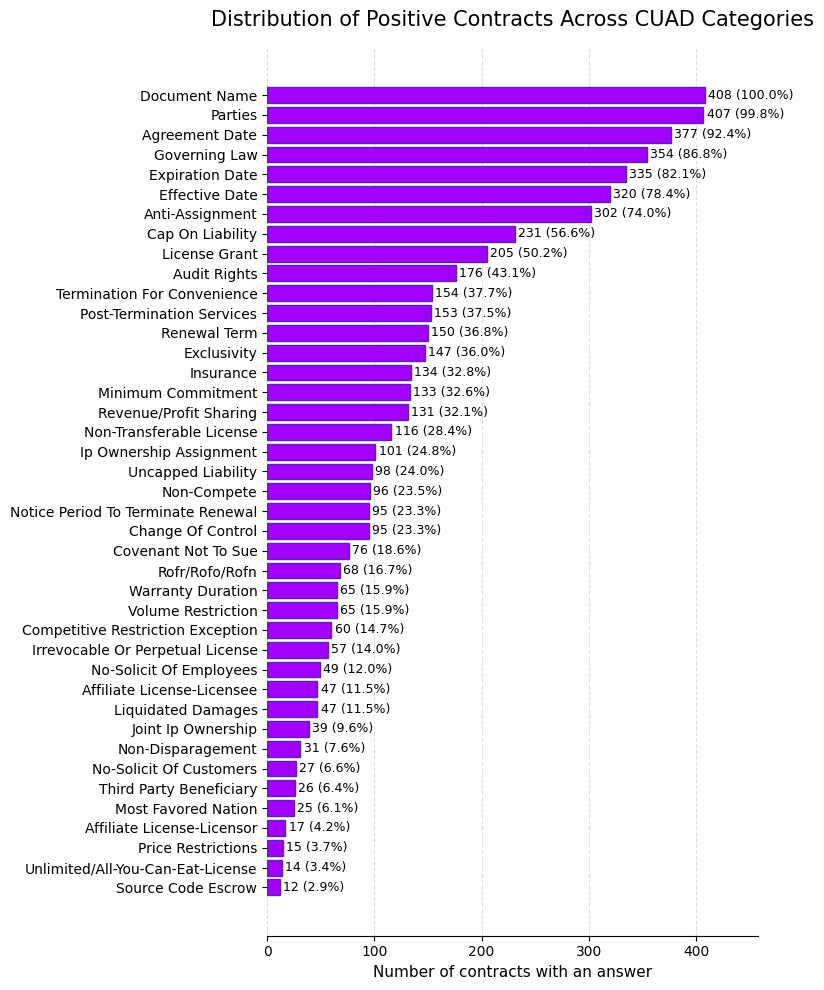

In [10]:
import matplotlib.pyplot as plt

# sort from rarest to most common
plot_data = stats.reset_index().sort_values("positive_contracts", ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))

bars = ax.barh(
    plot_data["category_name"],
    plot_data["positive_contracts"],
    color="#A100FF",
    edgecolor="#5B21B6"
)

# add percentage labels
for bar, rate in zip(bars, plot_data["positive_rate"]):
    ax.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())} ({rate:.1f}%)",
        va="center",
        fontsize=9
    )

# labels and title
ax.set_xlabel("Number of contracts with an answer", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Distribution of Positive Contracts Across CUAD Categories",
    fontsize=15,
    pad=15
)

# grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# put grid behind bars
ax.set_axisbelow(True)

# remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# x-axis starts at zero
ax.set_xlim(0, plot_data["positive_contracts"].max() + 50)

plt.tight_layout()
plt.show()

The chart shows how common each clause type is across the 408 contracts, so you can see at a glance which categories have more data and which have very little.

## Contract Length

Contract length was measured as the total number of words across all
paragraphs within each contract. This provides an indication of the
variation in document size within the training set.

In [11]:
# calculate contract length in words

contract_lengths = []

for contract in data["data"]:
    contract_id = contract["title"]

    full_text = " ".join(
        paragraph["context"]
        for paragraph in contract["paragraphs"]
    )

    word_count = len(full_text.split())

    contract_lengths.append({
        "contract": contract_id,
        "word_count": word_count
    })

length_df = pd.DataFrame(contract_lengths)

display(length_df)

print("Average contract length:",
      round(length_df["word_count"].mean(), 2), "words")

print("Median contract length:",
      length_df["word_count"].median(), "words")

print("Shortest contract:",
      length_df["word_count"].min(), "words")

print("Longest contract:",
      length_df["word_count"].max(), "words")

,contract,word_count
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,5998
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",11313
2,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,170
3,ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT A...,3770
4,"KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSU...",2766
...,...,...
403,CcRealEstateIncomeFundadv_20181205_POS 8C_EX-9...,4695
404,"BLUEROCKRESIDENTIALGROWTHREIT,INC_06_01_2016-E...",20909
405,"TALLGRASSENERGY,LP_02_20_2020-EX-99.26-JOINT F...",621
406,KINGPHARMACEUTICALSINC_08_09_2006-EX-10.1-PROM...,26840


Average contract length: 8045.09 words
Median contract length: 5357.5 words
Shortest contract: 170 words
Longest contract: 45650 words


**Findings:**
- The mean (8,045) is above the median (5,357.5), and a few very long contracts pull the mean upward.
- The shortest contract is 170 words and the longest is 45,650. Contract size varies a lot.

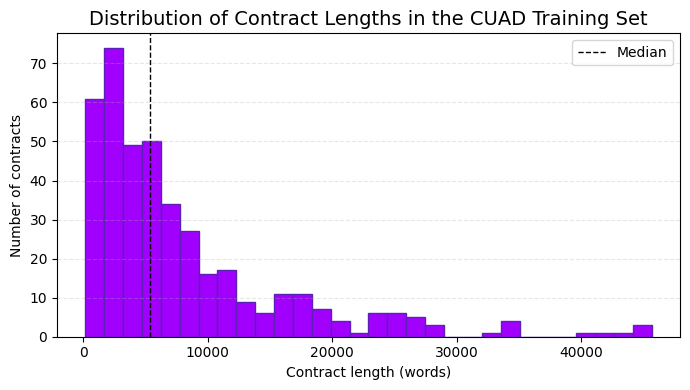

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.hist(
    length_df["word_count"],
    bins=30,
    color="#A100FF",
    edgecolor="#5B21B6"
)

plt.axvline(
    length_df["word_count"].median(),
    linestyle="--",
    linewidth=1,
    color="black",
    label="Median"
)

plt.xlabel("Contract length (words)")
plt.ylabel("Number of contracts")
plt.title(
    "Distribution of Contract Lengths in the CUAD Training Set",
    fontsize=14
)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

This histogram shows the shape of the contract length distribution. The distribution is right-skewed.

## Contract Length in Tokens

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

length_df["n_tokens"] = [
    len(tokenizer.encode(c["paragraphs"][0]["context"], add_special_tokens=False))
    for c in data["data"]
]

print("Median tokens:", length_df["n_tokens"].median())
print("Average tokens:", round(length_df["n_tokens"].mean()))
print("Shortest:", length_df["n_tokens"].min())
print("Longest:", length_df["n_tokens"].max())
print("Contracts over 512 tokens:", round((length_df["n_tokens"] > 512).mean() * 100, 1), "%")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (7556 > 512). Running this sequence through the model will result in indexing errors


Median tokens: 7301.0
Average tokens: 11147
Shortest: 224
Longest: 78591
Contracts over 512 tokens: 97.1 %


Contract length was also measured in tokens using bert-base-uncased, the tokenizer used in the chunking notebook. The median contract is 7,301 tokens and the average is 11,147, so a few very long contracts pull the mean up. Lengths range from 224 to 78,591 tokens. 97.1% of contracts exceed the 512-token limit, so chunking is required for nearly every contract.

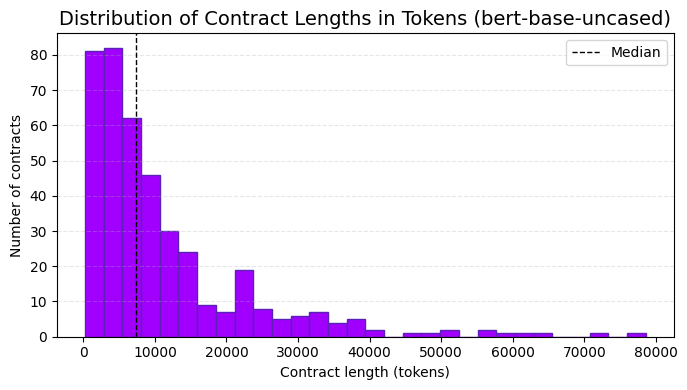

In [14]:
plt.figure(figsize=(7, 4))

plt.hist(length_df["n_tokens"], bins=30, color="#A100FF", edgecolor="#5B21B6")

plt.axvline(length_df["n_tokens"].median(), linestyle="--", linewidth=1, color="black", label="Median")

plt.xlabel("Contract length (tokens)")
plt.ylabel("Number of contracts")
plt.title("Distribution of Contract Lengths in Tokens (bert-base-uncased)", fontsize=14)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Nearly the whole distribution sits to the right of the 512-token limit. Only about 3% of contracts are short enough to fit in a single 512-token window, so the rest require chunking.

## Annotated Clause/Span Length

To understand the amount of text associated with each CUAD category,
the word length of every annotated answer span was calculated.

Median span length is used as the primary measure because it is less
sensitive to unusually long annotations.

In [15]:
# calculate span length by category

span_stats = []

for contract in data["data"]:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:
            for answer in qa.get("answers", []):

                span_stats.append({
                    "category": qa["question"],
                    "span_length": len(answer["text"].split())
                })

span_df = pd.DataFrame(span_stats)

# group by category
category_span_stats = (
    span_df.groupby("category")["span_length"]
    .agg(
        median_span_length="median",
        mean_span_length="mean",
        total_spans="count"
    )
    .reset_index()
)

# extract clean category names
category_span_stats["category_name"] = (
    category_span_stats["category"]
    .str.extract(r'"([^"]+)"')[0]
)

# sort by median span length
category_span_stats = category_span_stats.sort_values(
    "median_span_length"
)

display(category_span_stats.set_index("category_name").drop(columns="category"))

,median_span_length,mean_span_length,total_spans
category_name,,,
Parties,2.0,3.304823,2011
Agreement Date,3.0,3.718016,383
Document Name,3.0,3.238663,419
Effective Date,4.0,10.256198,363
Termination For Convenience,27.0,36.165854,205
Governing Law,29.0,33.513369,374
Third Party Beneficiary,31.0,35.357143,28
Expiration Date,31.0,37.695312,384
No-Solicit Of Customers,34.0,45.046512,43


**Findings:**
- Span length splits into two groups. Four metadata categories (Parties, Agreement Date, Document Name, Effective Date) have median spans of 2-4 words, so they are entity or date extraction. The other 37 categories have median spans of 27-80 words, so they are sentence- or clause-level extraction.
- Among the priority categories, median spans run from 27 words (Termination For Convenience) and 29 (Governing Law) up to 49 (Cap On Liability) and 50 (Change Of Control). Anti-Assignment (35) is also short. Renewal Term, Non-Compete, Exclusivity, Notice Period, and Liquidated Damages cluster at 44-47.5.
- The longest spans belong to the Affiliate License categories (median 80 words) and Irrevocable Or Perpetual License (68.5). None are in the priority set.

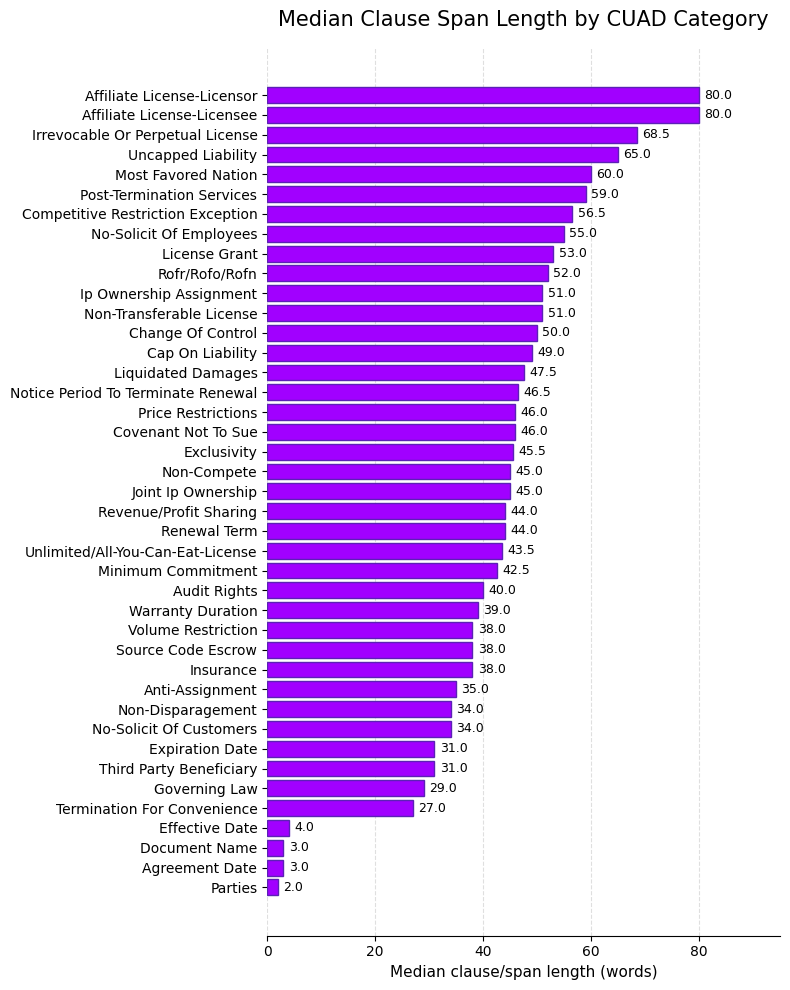

In [16]:
import matplotlib.pyplot as plt

plot_data = category_span_stats.sort_values(
    "median_span_length"
)

fig, ax = plt.subplots(figsize=(8, 10))

bars = ax.barh(
    plot_data["category_name"],
    plot_data["median_span_length"],
    color="#A100FF",
    edgecolor="#5B21B6"
)

# add median values to bars
for bar in bars:
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va="center",
        fontsize=9
    )

ax.set_xlabel("Median clause/span length (words)", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Median Clause Span Length by CUAD Category",
    fontsize=15,
    pad=15
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.set_xlim(
    0,
    plot_data["median_span_length"].max() + 15
)

plt.tight_layout()
plt.show()

This plots the median span length per category as a sorted horizontal bar chart, with each bar labeled by its value. It shows the contrast at a glance: short entity and date categories versus much longer clause-level categories.

## Identifying 10 Priority Categories

The advisor originally suggested about 10 high-value clause categories: Limitation of Liability, Indemnification, Termination Rights, Confidentiality, Governing Law, Dispute Resolution, Assignment, Change of Control, Auto-Renewal, and Exclusivity or Non-Compete / Non-Solicit obligations. Indemnification, Confidentiality, and Dispute Resolution have no corresponding CUAD label, so the scope was revised.

After discussing this with the advisor, the initial modeling scope uses 10 categories that are explicitly represented in CUAD: **Cap On Liability, Termination For Convenience, Governing Law, Anti-Assignment, Change Of Control, Renewal Term, Exclusivity, Non-Compete, Notice Period To Terminate Renewal, Liquidated Damages**

In [17]:
priority = [
    "Cap On Liability", "Termination For Convenience", "Governing Law",
    "Anti-Assignment", "Change Of Control", "Renewal Term",
    "Exclusivity", "Non-Compete", "Notice Period To Terminate Renewal", "Liquidated Damages"
]

display(stats.loc[priority, ["positive_contracts", "positive_rate"]])

,positive_contracts,positive_rate
category_name,,
Cap On Liability,231,56.617647
Termination For Convenience,154,37.745098
Governing Law,354,86.764706
Anti-Assignment,302,74.019608
Change Of Control,95,23.284314
Renewal Term,150,36.764706
Exclusivity,147,36.029412
Non-Compete,96,23.529412
Notice Period To Terminate Renewal,95,23.284314


## Clause Position Within Contracts

                                    median    n
category                                       
Exclusivity                           0.21  332
Non-Compete                           0.40  200
Renewal Term                          0.40  179
Notice Period To Terminate Renewal    0.47  104
Liquidated Damages                    0.51   98
Termination For Convenience           0.56  205
Change Of Control                     0.64  191
Cap On Liability                      0.65  554
Anti-Assignment                       0.79  517
Governing Law                         0.83  374


/tmp/ipykernel_2719/1481296908.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([pos_df[pos_df.category == c]["rel_pos"] for c in order],


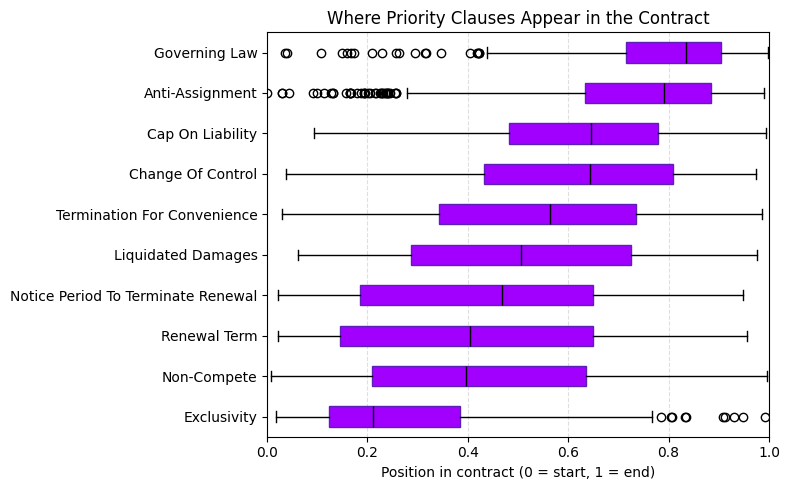

In [19]:
import matplotlib.pyplot as plt

rows = []
for c in data["data"]:
    ctx = c["paragraphs"][0]["context"]
    for qa in c["paragraphs"][0]["qas"]:
        name = qa["question"].split('"')[1]
        if name in priority:
            for a in qa["answers"]:
                rows.append({"category": name,
                             "rel_pos": a["answer_start"] / len(ctx)})

pos_df = pd.DataFrame(rows)

# order categories by median position
order = pos_df.groupby("category")["rel_pos"].median().sort_values().index

print(pos_df.groupby("category")["rel_pos"].agg(median="median", n="count").loc[order].round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([pos_df[pos_df.category == c]["rel_pos"] for c in order],
           vert=False, labels=order, patch_artist=True,
           boxprops=dict(facecolor="#A100FF", edgecolor="#5B21B6"),
           medianprops=dict(color="black"))
ax.set_xlabel("Position in contract (0 = start, 1 = end)")
ax.set_title("Where Priority Clauses Appear in the Contract")
ax.set_xlim(0, 1)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Findings:**
- Governing Law (0.83) and Anti-Assignment (0.79) sit latest. Exclusivity is earliest (0.21), ahead of Non-Compete and Renewal Term (both 0.40).
- Renewal Term (0.40) and Notice Period To Terminate Renewal (0.47) sit close together.
- Liquidated Damages (0.51) and Termination For Convenience (0.56) fall near the middle. Change Of Control (0.64) and Cap On Liability (0.65) sit in the second half.

## Multi-Label Category Co-Occurrence

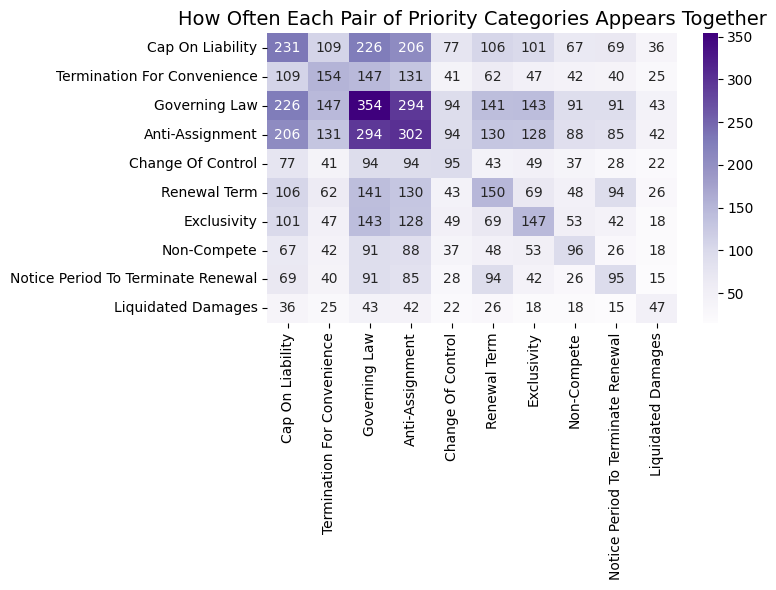

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# provisional priority categories (one place to edit if the list changes)
priority = [
    "Cap On Liability", "Termination For Convenience", "Governing Law",
    "Anti-Assignment", "Change Of Control", "Renewal Term",
    "Exclusivity", "Non-Compete", "Notice Period To Terminate Renewal", "Liquidated Damages"
]

# contract x category matrix
matrix = contract_category.pivot_table(
    index="contract",
    columns="category_name",
    values="has_answer",
    aggfunc="max"
).astype(int)

# how many contracts contain both categories
cooc = matrix.T.dot(matrix)

# keep only the priority categories
cooc_priority = cooc.loc[priority, priority]

plt.figure(figsize=(8, 6))
sns.heatmap(cooc_priority, annot=True, fmt="d", cmap="Purples")
plt.title("How Often Each Pair of Priority Categories Appears Together", fontsize=14)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Findings:**
- Highest Co-occuring Priority Pairs: The most frequent pairs are Governing Law + Anti-Assignment (294 contracts), Cap On Liability + Governing Law (226), and Cap On Liability + Anti-Assignment (206). These mostly reflect how common the categories are. Governing Law (86.8%) and Anti-Assignment (74.0%) appear in most contracts, so they co-occur with everything.


## Final Analysis

- **The categories are imbalanced.** Among the priority categories, positive rates range from 11.5% (Liquidated Damages, 47 contracts) to 86.8% (Governing Law, 354 contracts). The imbalance ratio runs from 0.15:1 to 7.7:1.
- **Contracts vary enormously in size.** The median is 7,301 tokens and the mean is 11,147. Lengths range from 224 to 78,591 tokens. The mean sits above the median because a few very long contracts pull it up.
- **Nearly all contracts exceed the 512-token limit.** 97.1% of contracts are longer than 512 tokens.
- **Span length differs by category type.** The four metadata categories have median spans of 2 to 4 words. The other 37 categories have median spans of 27 to 80 words. The priority categories fall between 27 (Termination For Convenience) and 50 (Change Of Control).
- **Clauses appear at different positions in the contract.** Median relative position ranges from 0.21 (Exclusivity) to 0.83 (Governing Law).
- **Label co-occurrence is highest for the most common categories.** Governing Law + Anti-Assignment (294 contracts), Cap On Liability + Governing Law (226), and Cap On Liability + Anti-Assignment (206) are the most frequent pairs. Governing Law (86.8%) and Anti-Assignment (74.0%) are the two most common priority categories.
- **The data is clean, with one duplicate.** All 11,180 spans align exactly with the source text, with none empty or duplicated. Two contracts have identical text (ADUROBIOTECH consulting agreement and its (1) copy).